# Testing batdetect2 pipeline features:

## **Working on features relevant to the use of this pipeline on recovered Audiomoth .wav recordings**

## 1) Figuring out our imports:

### a) Below are the imports pertaining to accessing data and metadata

In [1]:
from pathlib import Path
import glob
import exiftool
import suncalc
import soundfile as sf
import re

### b) Below are the imports pertaining to data manipulation

In [2]:
import numpy as np
import pandas as pd
import dask.dataframe as dd

### c) Below are the imports pertaining to data visualization

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

### d) Below are the imports pertaining to the use of the MSDS pipeline

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
import src.file_dealer as file_dealer
import bout.assembly as bt
import bout.clustering as clstr
from cfg import get_config

In [5]:
SEATTLE_LATITUDE = 47.655181
SEATTLE_LONGITUDE = -122.293123
SITE_NAMES = {
            'Central' : "Central Pond",
            'Foliage' : "Foliage",
            'Carp' : "Carp Pond",
            'Telephone' : "Telephone Field",
            'E18' : "E18 Bridge"
                }


Searching for files from recover-20250516 and UBNA_026


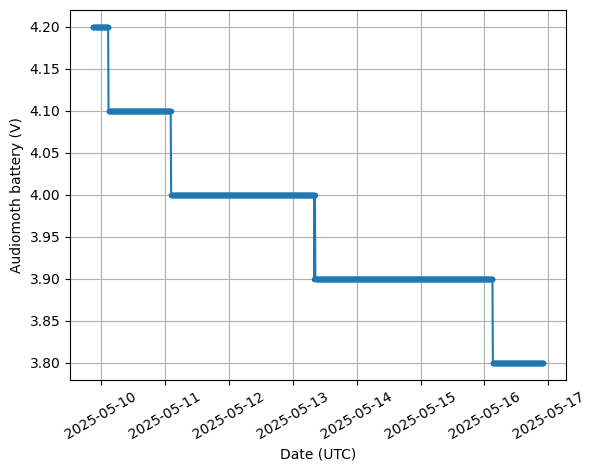

In [6]:
cfg=dict()
cfg["sd_unit"] = '026'
cfg["cycle_length"] = 600
cfg['recording_start'] = '00:00'
cfg['recording_end'] = '23:59'

data_params = dict()
data_params['recover_folder'] = 'recover-20250516'
data_params["audiomoth_folder"] = f"UBNA_{cfg['sd_unit']}"
print(f"Searching for files from {data_params['recover_folder']} and {data_params['audiomoth_folder']}")

cur_data_records = dd.read_csv(f'../output_dir/ubna_data_06_collected_audio_records.csv', dtype=str).compute()
if 'Unnamed: 0' in cur_data_records.columns:
    cur_data_records.drop(columns='Unnamed: 0', inplace=True)
cur_data_records["datetime_UTC"] = pd.DatetimeIndex(cur_data_records["datetime_UTC"])
cur_data_records.set_index("datetime_UTC", inplace=True) 

files_from_deployment_session = batdetect2_pipeline.filter_df_with_deployment_session(cur_data_records, data_params['recover_folder'], cfg)
audiomoth_batteries = []
for battery_val in files_from_deployment_session['audiomoth_battery'].values:
    audiomoth_batteries += [float(battery_val.replace('V',''))]
audiomoth_batteries = np.array(audiomoth_batteries)
files_from_deployment_session['audiomoth_battery'] = audiomoth_batteries
plt.plot(files_from_deployment_session['audiomoth_battery'], marker='.')
plt.ylabel('Audiomoth battery (V)')
plt.xlabel('Date (UTC)')
plt.xticks(rotation=30)
plt.grid(which='both')
plt.show()

In [7]:
from models.bat_call_detector.model_detector import BatCallDetector

In [15]:
detector_args = dict()
detector_args['detection_threshold'] = 0.30
detector_args['chunk_size'] = 2

cfg = dict()
cfg["time_expansion_factor"] = 1.0
# Offset (seconds) from the beginning of the audio file to start processing
cfg["start_time"] = 0.0
# Input audio is divided into segments of this duration (seconds), each processed individually
cfg["segment_duration"] = 30.0
cfg["models"] = [BatCallDetector(detection_threshold=detector_args['detection_threshold'],
                                spec_slices=False,
                                chunk_size=detector_args['chunk_size'],
                                time_expansion_factor=1.0,
                                quiet=False,
                                cnn_features=True)]


cfg["recover_folder"] = 'recover-20260420'
cfg["sd_unit"] = "027"
cfg["site"] = 'Telephone Field'
cfg['recording_start'] = '00:00'
cfg['recording_end'] = '23:59'
cfg['duration'] = 300
cfg['cycle_length'] = 600
cfg["output_dir"] = Path('../output_dir/recover-20260420')
cfg["tmp_dir"] = Path('../output/tmp')
cfg["generate_fig"] = True

In [16]:
# run_pipeline_for_session_with_df(cfg)

data_params = batdetect2_pipeline.get_params_relevant_to_data(cfg)
cfg["csv_filename"] = f"bd2__{data_params['recover_folder']}_{data_params['audiomoth_folder']}"


Searching for files from recover-20260420 and UBNA_027


Will save csv file to ../output_dir/recover-20260420/Telephone Field
Error files exist!


In [17]:
bd_preds = pd.DataFrame()

if not data_params['output_dir'].is_dir():
    data_params['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

packages_to_chunk = []
for path in data_params['good_audio_files']:
    chunk_instructions_and_files = dict()
    chunk_instructions_and_files['audio_file'] = path
    chunk_instructions_and_files['tmp_dir'] = cfg['tmp_dir']
    chunk_instructions_and_files['start_time'] = cfg['start_time']
    chunk_instructions_and_files['segment_duration'] = cfg['segment_duration']
    packages_to_chunk+=[chunk_instructions_and_files]


In [18]:
data_params['resample_in_min'] = 30
data_params['resample_tag'] = f"{data_params['resample_in_min']}min"
data_params['detection_threshold_for_activity'] = 0.35
data_params['SNR_threshold_for_activity'] = 3

In [64]:
csv_tag = cfg["csv_filename"].split('__')[-1]
ref_datetimes = pd.to_datetime(data_params['ref_audio_files'], format="%Y%m%d_%H%M%S", exact=False)
activity_datetimes_for_file = ref_datetimes.tz_localize('UTC')
good_datetimes = pd.to_datetime(data_params['good_audio_files'], format="%Y%m%d_%H%M%S", exact=False)
nodets = 0

rawdets = pd.read_csv(f'{data_params["output_dir"]}/{cfg["csv_filename"]}.csv')
dets = rawdets[(rawdets['det_prob']>=data_params['detection_threshold_for_activity'])&(rawdets['SNR']>=data_params['SNR_threshold_for_activity'])].copy()
dets['ref_time'] = pd.to_datetime(dets['input_file'], format="%Y%m%d_%H%M%S", exact=False)
activity_callrate_arr = pd.DataFrame()
activity_btp_arr = pd.DataFrame()
activity_ai_arr = pd.DataFrame()
dets

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time
2,HF,65280.0,12.852086,8.1885,8.2028,65000.0,70208.0,Pipistrellus pygmaeus,0.418,0.423,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
3,HF,48960.0,9.579656,26.7745,26.7826,48671.0,52057.0,Pipistrellus pipistrellus,0.447,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
5,HF,48960.0,12.381939,30.8685,30.8781,47812.0,50635.0,Pipistrellus pipistrellus,0.374,0.506,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
6,HF,48960.0,18.408391,36.4215,36.4313,48671.0,50507.0,Pipistrellus pipistrellus,0.368,0.439,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
7,LF,25920.0,11.970025,37.0355,37.0475,25468.0,30302.0,Nyctalus leisleri,0.308,0.374,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58701,LF,22080.0,10.987883,190.1045,190.1279,22031.0,25342.0,Nyctalus leisleri,0.347,0.369,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 20:50:00
58704,LF,17280.0,3.543664,78.4675,78.4833,16875.0,20987.0,Nyctalus noctula,0.229,0.386,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00
58707,LF,19200.0,3.680265,117.8815,117.9022,17734.0,20383.0,Nyctalus noctula,0.252,0.360,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00
58708,LF,19200.0,4.718593,118.5275,118.5476,17734.0,20847.0,Nyctalus noctula,0.291,0.434,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00


In [65]:
group = 'LF'
freq_group_df = dets.loc[dets['KMEANS_CLASSES']==group].copy()
freq_group_df

,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time
7,LF,25920.0,11.970025,37.0355,37.0475,25468.0,30302.0,Nyctalus leisleri,0.308,0.374,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
11,LF,23040.0,5.842958,58.4015,58.4153,22890.0,27398.0,Nyctalus leisleri,0.337,0.404,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:00
33,LF,25920.0,9.589418,14.4295,14.4432,25468.0,28635.0,Nyctalus leisleri,0.287,0.356,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:00
34,LF,25920.0,11.598319,19.6835,19.6975,24609.0,29473.0,Nyctalus leisleri,0.322,0.391,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:00
35,LF,25920.0,7.337333,28.3915,28.4050,25468.0,27698.0,Nyctalus leisleri,0.344,0.384,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58701,LF,22080.0,10.987883,190.1045,190.1279,22031.0,25342.0,Nyctalus leisleri,0.347,0.369,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 20:50:00
58704,LF,17280.0,3.543664,78.4675,78.4833,16875.0,20987.0,Nyctalus noctula,0.229,0.386,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00
58707,LF,19200.0,3.680265,117.8815,117.9022,17734.0,20383.0,Nyctalus noctula,0.252,0.360,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00
58708,LF,19200.0,4.718593,118.5275,118.5476,17734.0,20847.0,Nyctalus noctula,0.291,0.434,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:00:00


In [66]:
valid_df = batdetect2_pipeline.prepare_and_threshold_dets_for_activity(freq_group_df, data_params)
valid_df

,start_time_wrt_ref,end_time_wrt_ref,call_start_time,call_end_time,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,...,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name,ref_time,freq_group,cycle_ref_time
7,37.0355,37.0475,2026-04-13 19:00:37.035500000,2026-04-13 19:00:37.047500,LF,25920.0,11.970025,37.0355,37.0475,25468.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:37.035500000,LF,2026-04-13 19:00:00
11,58.4015,58.4153,2026-04-13 19:00:58.401500000,2026-04-13 19:00:58.415300,LF,23040.0,5.842958,58.4015,58.4153,22890.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:00:58.401500000,LF,2026-04-13 19:00:00
33,14.4295,14.4432,2026-04-13 19:30:14.429500000,2026-04-13 19:30:14.443200,LF,25920.0,9.589418,14.4295,14.4432,25468.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:14.429500000,LF,2026-04-13 19:30:00
34,19.6835,19.6975,2026-04-13 19:30:19.683500000,2026-04-13 19:30:19.697500,LF,25920.0,11.598319,19.6835,19.6975,24609.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:19.683500000,LF,2026-04-13 19:30:00
35,28.3915,28.4050,2026-04-13 19:30:28.391500000,2026-04-13 19:30:28.405000,LF,25920.0,7.337333,28.3915,28.4050,25468.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-13 19:30:28.391500000,LF,2026-04-13 19:30:00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58701,1390.1045,1390.1279,2026-04-20 20:53:10.104500000,2026-04-20 20:53:10.127900,LF,22080.0,10.987883,190.1045,190.1279,22031.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 20:53:10.104500000,LF,2026-04-20 20:30:00
58704,78.4675,78.4833,2026-04-20 21:01:18.467500000,2026-04-20 21:01:18.483300,LF,17280.0,3.543664,78.4675,78.4833,16875.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:01:18.467500000,LF,2026-04-20 21:00:00
58707,117.8815,117.9022,2026-04-20 21:01:57.881500000,2026-04-20 21:01:57.902200,LF,19200.0,3.680265,117.8815,117.9022,17734.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:01:57.881500000,LF,2026-04-20 21:00:00
58708,118.5275,118.5476,2026-04-20 21:01:58.527499999,2026-04-20 21:01:58.547600,LF,19200.0,4.718593,118.5275,118.5476,17734.0,...,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field,2026-04-20 21:01:58.527499999,LF,2026-04-20 21:00:00


In [67]:
all_site_bd2_df = dd.read_csv(f"../output_dir/recover-2026*/{SITE_NAMES[data_params['site_tag']]}/bd2__*.csv").compute()
all_site_bd2_df


,KMEANS_CLASSES,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
0,HF,65280.0,1.051490,1.4925,1.4998,59843.0,65012.0,Pipistrellus pygmaeus,0.255,0.306,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
1,HF,45120.0,-1.481562,3.0665,3.0807,44375.0,48172.0,Pipistrellus pipistrellus,0.272,0.364,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
2,HF,46080.0,8.602745,5.6995,5.7089,45234.0,55703.0,Pipistrellus pipistrellus,0.186,0.303,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
3,LF,22080.0,3.316475,33.5915,33.6062,22031.0,26355.0,Nyctalus leisleri,0.256,0.351,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
4,HF,65280.0,-2.601184,36.4855,36.4973,61562.0,67793.0,Pipistrellus pygmaeus,0.198,0.301,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58707,LF,19200.0,3.680265,117.8815,117.9022,17734.0,20383.0,Nyctalus noctula,0.252,0.360,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58708,LF,19200.0,4.718593,118.5275,118.5476,17734.0,20847.0,Nyctalus noctula,0.291,0.434,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58709,LF,17280.0,7.688107,138.9675,138.9853,16875.0,20529.0,Nyctalus noctula,0.179,0.383,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58710,LF,24000.0,0.994626,63.1865,63.1985,23750.0,28105.0,Nyctalus leisleri,0.154,0.300,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [68]:
# bout_params = batdetect2_pipeline.get_bout_params_from_location(all_site_bd2_df, data_params)
raw_bd2_df = all_site_bd2_df.copy()

raw_bd2_df = raw_bd2_df[(raw_bd2_df['det_prob']>=data_params['detection_threshold_for_activity'])&(raw_bd2_df['SNR']>=data_params['SNR_threshold_for_activity'])]
raw_bd2_df = raw_bd2_df.rename(columns={'KMEANS_CLASSES': 'freq_group'})
file_dts = pd.to_datetime(raw_bd2_df['input_file'], format='%Y%m%d_%H%M%S', exact=False)

anchor_start_times = file_dts + pd.to_timedelta(raw_bd2_df['start_time'].values.astype('float64'), unit='s')
anchor_end_times = file_dts + pd.to_timedelta(raw_bd2_df['end_time'].values.astype('float64'), unit='s') 

raw_bd2_df.insert(0, 'call_end_time', anchor_end_times)
raw_bd2_df.insert(0, 'call_start_time', anchor_start_times)
raw_bd2_df.insert(0, 'ref_time', anchor_start_times)

valid_df = raw_bd2_df[(raw_bd2_df['freq_group']=='LF')|(raw_bd2_df['freq_group']=='HF')]
valid_df = valid_df.sort_values('call_start_time')
valid_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
3,2025-12-26 20:10:33.591500000,2025-12-26 20:10:33.591500000,2025-12-26 20:10:33.606200,LF,22080.0,3.316475,33.5915,33.6062,22031.0,26355.0,Nyctalus leisleri,0.256,0.351,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
15,2025-12-26 20:11:52.580500000,2025-12-26 20:11:52.580500000,2025-12-26 20:11:52.595600,LF,23040.0,4.075836,112.5805,112.5956,22890.0,27162.0,Nyctalus leisleri,0.362,0.459,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
24,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.905900,HF,46080.0,3.492031,165.8985,165.9059,46953.0,53356.0,Pipistrellus pipistrellus,0.319,0.441,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
31,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.429500,HF,60480.0,4.286377,217.4155,217.4295,55546.0,58978.0,Pipistrellus pygmaeus,0.358,0.380,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
38,2025-12-26 20:14:10.138500000,2025-12-26 20:14:10.138500000,2025-12-26 20:14:10.156100,LF,23040.0,3.907339,250.1385,250.1561,23750.0,27092.0,Nyctalus leisleri,0.324,0.374,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58701,2026-04-20 20:53:10.104500000,2026-04-20 20:53:10.104500000,2026-04-20 20:53:10.127900,LF,22080.0,10.987883,190.1045,190.1279,22031.0,25342.0,Nyctalus leisleri,0.347,0.369,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58704,2026-04-20 21:01:18.467500000,2026-04-20 21:01:18.467500000,2026-04-20 21:01:18.483300,LF,17280.0,3.543664,78.4675,78.4833,16875.0,20987.0,Nyctalus noctula,0.229,0.386,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58707,2026-04-20 21:01:57.881500000,2026-04-20 21:01:57.881500000,2026-04-20 21:01:57.902200,LF,19200.0,3.680265,117.8815,117.9022,17734.0,20383.0,Nyctalus noctula,0.252,0.360,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58708,2026-04-20 21:01:58.527499999,2026-04-20 21:01:58.527499999,2026-04-20 21:01:58.547600,LF,19200.0,4.718593,118.5275,118.5476,17734.0,20847.0,Nyctalus noctula,0.291,0.434,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [69]:
bout_params = bt.get_bout_params_from_location(valid_df, data_params)

In [62]:
# bout_params = bt.get_bout_params_from_location(valid_df, data_params)

location_sum_df = valid_df.copy()
bout_params = dict()
bout_params['site_key'] = data_params['site_tag']


In [27]:
location_sum_df['freq_group'].unique()

array(['LF', 'HF'], dtype=object)

In [28]:

group = 'HF'
freq_group_df = location_sum_df.loc[location_sum_df['freq_group']==group].copy()
freq_group_df


,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
24,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.905900,HF,46080.0,3.492031,165.8985,165.9059,46953.0,53356.0,Pipistrellus pipistrellus,0.319,0.441,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
31,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.429500,HF,60480.0,4.286377,217.4155,217.4295,55546.0,58978.0,Pipistrellus pygmaeus,0.358,0.380,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
62,2025-12-26 20:20:59.407500000,2025-12-26 20:20:59.407500000,2025-12-26 20:20:59.417800,HF,48960.0,4.697662,59.4075,59.4178,47812.0,52261.0,Pipistrellus pipistrellus,0.337,0.400,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
81,2025-12-26 20:23:52.046500000,2025-12-26 20:23:52.046500000,2025-12-26 20:23:52.051400,HF,46080.0,7.508557,232.0465,232.0514,25468.0,72063.0,Myotis nattereri,0.264,0.394,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
83,2025-12-26 20:24:00.841500000,2025-12-26 20:24:00.841500000,2025-12-26 20:24:00.845200,HF,46080.0,4.943974,240.8415,240.8452,38359.0,55602.0,Myotis daubentonii,0.316,0.400,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58311,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.477700,HF,50880.0,6.016598,111.4715,111.4777,49531.0,61301.0,Pipistrellus pipistrellus,0.542,0.566,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58314,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.243200,HF,45120.0,7.042220,72.2345,72.2432,43515.0,63219.0,Pipistrellus pipistrellus,0.443,0.619,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58315,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.429700,HF,46080.0,10.206348,72.4225,72.4297,44375.0,61491.0,Pipistrellus pipistrellus,0.580,0.654,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58316,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.517400,HF,48000.0,7.816059,72.5095,72.5174,46093.0,59887.0,Pipistrellus pipistrellus,0.445,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [37]:
# ipis_loc, hist_loc = clstr.get_histogram(freq_group_df, 10)
location_sum_df = freq_group_df.copy()
location_sum_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
24,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.898500000,2025-12-26 20:12:45.905900,HF,46080.0,3.492031,165.8985,165.9059,46953.0,53356.0,Pipistrellus pipistrellus,0.319,0.441,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
31,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.415500000,2025-12-26 20:13:37.429500,HF,60480.0,4.286377,217.4155,217.4295,55546.0,58978.0,Pipistrellus pygmaeus,0.358,0.380,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
62,2025-12-26 20:20:59.407500000,2025-12-26 20:20:59.407500000,2025-12-26 20:20:59.417800,HF,48960.0,4.697662,59.4075,59.4178,47812.0,52261.0,Pipistrellus pipistrellus,0.337,0.400,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
81,2025-12-26 20:23:52.046500000,2025-12-26 20:23:52.046500000,2025-12-26 20:23:52.051400,HF,46080.0,7.508557,232.0465,232.0514,25468.0,72063.0,Myotis nattereri,0.264,0.394,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
83,2025-12-26 20:24:00.841500000,2025-12-26 20:24:00.841500000,2025-12-26 20:24:00.845200,HF,46080.0,4.943974,240.8415,240.8452,38359.0,55602.0,Myotis daubentonii,0.316,0.400,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260108/UBNA_032/20...,recover-20260108,UBNA_032,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58311,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.477700,HF,50880.0,6.016598,111.4715,111.4777,49531.0,61301.0,Pipistrellus pipistrellus,0.542,0.566,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58314,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.243200,HF,45120.0,7.042220,72.2345,72.2432,43515.0,63219.0,Pipistrellus pipistrellus,0.443,0.619,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58315,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.429700,HF,46080.0,10.206348,72.4225,72.4297,44375.0,61491.0,Pipistrellus pipistrellus,0.580,0.654,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58316,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.517400,HF,48000.0,7.816059,72.5095,72.5174,46093.0,59887.0,Pipistrellus pipistrellus,0.445,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [ ]:
location_sum_df = freq_group_df.copy()
test_subset_df = location_sum_df.loc[location_sum_df['Recover Folder']=='recover-20260420'].copy()
bin_step = 10
test_subsubset_df = test_subset_df.copy()
#25k - 50k = yes
#25k - 37500 = yes
#25k - 31250 = no
#31250 - 37500 = yes
#31250 - 34375 = no
#34375 - 37500 = yes
#34375 - 35938 = yes
#34375 - 35157 = no
#35157 - 35938 = yes
#35157 - 35548 = yes
#35157 - 35353 = yes
#35157 - 35255 = yes
#35157 - 35206 = no
#35206 - 35255 = yes
#35206 - 35231 = no
#35231 - 35255 = yes
#35231 - 35243 = yes
    #35243 - 35255 = no
#35231 - 35237 = no
    #35237 - 35243 = yes
#35237 - 35240 = no
    #35240 - 35243 = yes
test_subsubset_df

,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
2,2026-04-13 19:00:08.188500000,2026-04-13 19:00:08.188500000,2026-04-13 19:00:08.202800,HF,65280.0,12.852086,8.1885,8.2028,65000.0,70208.0,Pipistrellus pygmaeus,0.418,0.423,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
3,2026-04-13 19:00:26.774500000,2026-04-13 19:00:26.774500000,2026-04-13 19:00:26.782600,HF,48960.0,9.579656,26.7745,26.7826,48671.0,52057.0,Pipistrellus pipistrellus,0.447,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
5,2026-04-13 19:00:30.868500000,2026-04-13 19:00:30.868500000,2026-04-13 19:00:30.878100,HF,48960.0,12.381939,30.8685,30.8781,47812.0,50635.0,Pipistrellus pipistrellus,0.374,0.506,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
6,2026-04-13 19:00:36.421500000,2026-04-13 19:00:36.421500000,2026-04-13 19:00:36.431300,HF,48960.0,18.408391,36.4215,36.4313,48671.0,50507.0,Pipistrellus pipistrellus,0.368,0.439,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
9,2026-04-13 19:00:55.486500000,2026-04-13 19:00:55.486500000,2026-04-13 19:00:55.495100,HF,48960.0,13.949494,55.4865,55.4951,47812.0,51092.0,Pipistrellus pipistrellus,0.309,0.437,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58311,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.477700,HF,50880.0,6.016598,111.4715,111.4777,49531.0,61301.0,Pipistrellus pipistrellus,0.542,0.566,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58314,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.243200,HF,45120.0,7.042220,72.2345,72.2432,43515.0,63219.0,Pipistrellus pipistrellus,0.443,0.619,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58315,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.429700,HF,46080.0,10.206348,72.4225,72.4297,44375.0,61491.0,Pipistrellus pipistrellus,0.580,0.654,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58316,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.517400,HF,48000.0,7.816059,72.5095,72.5174,46093.0,59887.0,Pipistrellus pipistrellus,0.445,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [45]:
location_sum_df = test_subsubset_df.copy()

In [46]:
ipis_ms = clstr.get_valid_ipis_ms(test_subsubset_df)

In [47]:
intervals = pd.to_datetime(location_sum_df['call_start_time']) - pd.to_datetime(location_sum_df['call_end_time']).shift(1)
location_sum_df.insert(0, 'time_from_prev_call_end_time', intervals)
location_sum_df.insert(0, 'index', location_sum_df.index)

location_sum_df['ref_time'] = pd.DatetimeIndex(location_sum_df['call_start_time'])

first_calls_per_day = location_sum_df.resample(on='ref_time', rule='D').first()['index']
first_valid_calls_per_day = pd.DatetimeIndex(first_calls_per_day.loc[~first_calls_per_day.isna()].values)

In [49]:
test_subsubset_df['ref_time'] = pd.DatetimeIndex(test_subsubset_df['call_start_time'])
# test_subsubset_df = test_subsubset_df.set_index('ref_time')
test_subsubset_df

,time_from_prev_call_end_time,ref_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,...,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
2,NaT,2026-04-13 19:00:08.188500000,2026-04-13 19:00:08.188500000,2026-04-13 19:00:08.202800,HF,65280.0,12.852086,8.1885,8.2028,65000.0,...,Pipistrellus pygmaeus,0.418,0.423,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
3,0 days 00:00:18.571700,2026-04-13 19:00:26.774500000,2026-04-13 19:00:26.774500000,2026-04-13 19:00:26.782600,HF,48960.0,9.579656,26.7745,26.7826,48671.0,...,Pipistrellus pipistrellus,0.447,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
5,0 days 00:00:04.085900,2026-04-13 19:00:30.868500000,2026-04-13 19:00:30.868500000,2026-04-13 19:00:30.878100,HF,48960.0,12.381939,30.8685,30.8781,47812.0,...,Pipistrellus pipistrellus,0.374,0.506,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
6,0 days 00:00:05.543400,2026-04-13 19:00:36.421500000,2026-04-13 19:00:36.421500000,2026-04-13 19:00:36.431300,HF,48960.0,18.408391,36.4215,36.4313,48671.0,...,Pipistrellus pipistrellus,0.368,0.439,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
9,0 days 00:00:19.055200,2026-04-13 19:00:55.486500000,2026-04-13 19:00:55.486500000,2026-04-13 19:00:55.495100,HF,48960.0,13.949494,55.4865,55.4951,47812.0,...,Pipistrellus pipistrellus,0.309,0.437,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
58311,0 days 00:00:00.187700,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.471500000,2026-04-20 12:11:51.477700,HF,50880.0,6.016598,111.4715,111.4777,49531.0,...,Pipistrellus pipistrellus,0.542,0.566,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58314,0 days 00:19:20.756800,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.234500000,2026-04-20 12:31:12.243200,HF,45120.0,7.042220,72.2345,72.2432,43515.0,...,Pipistrellus pipistrellus,0.443,0.619,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58315,0 days 00:00:00.179300,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.422500000,2026-04-20 12:31:12.429700,HF,46080.0,10.206348,72.4225,72.4297,44375.0,...,Pipistrellus pipistrellus,0.580,0.654,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
58316,0 days 00:00:00.079799999,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.509499999,2026-04-20 12:31:12.517400,HF,48000.0,7.816059,72.5095,72.5174,46093.0,...,Pipistrellus pipistrellus,0.445,0.523,-1,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [51]:
test_subsubset_df.resample(on='ref_time', rule='D').first()

,time_from_prev_call_end_time,call_start_time,call_end_time,freq_group,peak_frequency,SNR,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,sampling_rate,input_file,Recover Folder,SD Card,Site name
ref_time,,,,,,,,,,,,,,,,,,,,
2026-04-13,0 days 00:00:18.571700,2026-04-13 19:00:08.188500,2026-04-13 19:00:08.202800,HF,65280.0,12.852086,8.1885,8.2028,65000.0,70208.0,Pipistrellus pygmaeus,0.418,0.423,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-14,0 days 07:26:37.911200,2026-04-14 03:30:00.019500,2026-04-14 03:30:00.024900,HF,47040.0,17.694304,0.0195,0.0249,43515.0,63031.0,Pipistrellus pipistrellus,0.350,0.520,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-15,0 days 23:49:15.057700,2026-04-15 09:44:14.192500,2026-04-15 09:44:14.200600,HF,46080.0,3.325805,254.1925,254.2006,44375.0,50569.0,Pipistrellus pipistrellus,0.301,0.398,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-16,NaT,NaT,NaT,None,NaN,NaN,NaN,NaN,NaN,NaN,None,NaN,NaN,NaN,None,NaN,None,None,None,None
2026-04-17,1 days 17:48:40.503900,2026-04-17 03:32:54.704500,2026-04-17 03:32:54.709700,HF,47040.0,4.999651,174.7045,174.7097,45234.0,55033.0,Pipistrellus pipistrellus,0.541,0.566,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-18,0 days 15:51:36.641800,2026-04-18 03:44:31.602500,2026-04-18 03:44:31.608400,HF,54720.0,5.228252,271.6025,271.6084,52968.0,64038.0,Pipistrellus pipistrellus,0.336,0.404,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-19,0 days 16:00:31.623400,2026-04-19 03:31:01.950500,2026-04-19 03:31:01.958200,HF,48960.0,4.348441,61.9505,61.9582,47812.0,51994.0,Pipistrellus pipistrellus,0.329,0.354,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field
2026-04-20,0 days 15:13:10.181600,2026-04-20 03:43:59.546500,2026-04-20 03:43:59.551100,HF,48960.0,3.628882,239.5465,239.5511,47812.0,60010.0,Pipistrellus pipistrellus,0.500,0.528,-1.0,Echolocation,192000.0,/mnt/ubna_data_07/recover-20260420/UBNA_027/20...,recover-20260420,UBNA_027,Telephone Field


In [57]:
first_calls_per_day = test_subsubset_df.resample(on='ref_time', rule='D').first()['SNR']
first_calls_per_day

ref_time
2026-04-13    12.852086
2026-04-14    17.694304
2026-04-15     3.325805
2026-04-16          NaN
2026-04-17     4.999651
2026-04-18     5.228252
2026-04-19     4.348441
2026-04-20     3.628882
Freq: D, Name: SNR, dtype: float64

In [58]:
first_valid_calls_per_day = (first_calls_per_day.loc[~first_calls_per_day.isna()].values)
first_valid_calls_per_day

array([12.85208611, 17.69430407,  3.32580545,  4.99965096,  5.22825172,
        4.34844133,  3.6288821 ])

In [59]:
test_subsubset_df.loc[first_valid_calls_per_day, 'time_from_prev_call_end_time'] = pd.NaT
test_subsubset_df

KeyError: "None of [Index([ 12.85208610636441,  17.69430406840662, 3.3258054518251794,\n        4.999650955416871,  5.228251722685973,    4.3484413276176,\n        3.628882101772511],\n      dtype='float64')] are in the [index]"

In [ ]:
intervals = test_subsubset_df['time_from_prev_call_end_time'].values
valid_intervals = intervals[~np.isnan(intervals)]
ipis_ms = np.abs(valid_intervals.astype('float32')/1e6)
(ipis_ms).shape, (first_valid_calls_per_day).shape

((2,), (2,))

In [ ]:
ipis_ms

array([ 5.5, 36.5], dtype=float32)

In [ ]:
len(test_subsubset_df) - (len(ipis_ms) + len(first_valid_calls_per_day))

0

In [ ]:
'

SyntaxError: EOL while scanning string literal (544193499.py, line 1)

In [ ]:

# test_ipis_ms(ipis_ms, first_valid_calls_per_day, location_sum_df)
assert(len(ipis_ms) + len(first_valid_calls_per_day) == len(test_subsubset_df))


In [ ]:

hist_loc = np.histogram(ipis_ms, bins=np.arange(0, ipis_ms.max()+bin_step, bin_step))





In [ ]:
intervals_ms, survival = clstr.get_log_survival(hist_loc)
fast_process = clstr.regress_around_fast_intervals(intervals_ms, survival, hist_loc[0])
fast_process = clstr.calculate_exponential_coefficients(fast_process)
slow_process = clstr.regress_around_slow_intervals(intervals_ms, survival)
slow_process = clstr.calculate_exponential_coefficients(slow_process)
bci, misassigned_points = clstr.get_bci_from_slater_method(intervals_ms, survival, fast_process, slow_process)
bout_params[f'{group}_bci'] = bci



In [ ]:
batdetect2_preds_with_bouttags = bt.classify_bouts_in_detector_preds_for_freqgroups(valid_df, bout_params)
bout_metrics = bt.construct_bout_metrics_from_location_df_for_freqgroups(batdetect2_preds_with_bouttags)
bout_metrics['ref_time'] = pd.DatetimeIndex(bout_metrics['start_time_of_bout'])
bout_metrics['total_bout_duration_in_secs'] = bout_metrics['bout_duration_in_secs']
bout_metrics = bout_metrics.set_index('ref_time')
bout_duration_per_file = bout_metrics.resample(f"30min")['total_bout_duration_in_secs'].sum()
btp_per_file = 100 * (bout_duration_per_file / (cfg['duration']))





In [ ]:
actvt_group_btp = btp_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
actvt_group_btp_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_btp)), columns=["date_and_time_UTC", f"{group}bout_time_percentage"])
actvt_group_btp_arr = actvt_group_btp_arr.set_index("date_and_time_UTC")
activity_btp_arr = pd.concat([activity_btp_arr, actvt_group_btp_arr], axis=1)




In [ ]:
for group in ['', 'LF', 'HF']:
    if group != '':
        freq_group_df = dets.loc[dets['KMEANS_CLASSES']==group].copy()
    else:
        freq_group_df = dets.copy()
    callrate_per_file = batdetect2_pipeline.get_callrate_per_file_from_freq_group_df(freq_group_df, cfg)
    actvt_group_callrate = callrate_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    actvt_group_callrate_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_callrate)), columns=["date_and_time_UTC", f"{group}callrate"])
    actvt_group_callrate_arr = actvt_group_callrate_arr.set_index("date_and_time_UTC")
    activity_callrate_arr = pd.concat([activity_callrate_arr, actvt_group_callrate_arr], axis=1)

    valid_df = batdetect2_pipeline.prepare_and_threshold_dets_for_activity(freq_group_df, data_params)
    # btp_per_file = batdetect2_pipeline.get_btp_per_file_from_freq_group_df(valid_df, data_params, cfg)
    # actvt_group_btp = btp_per_file.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    # actvt_group_btp_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_btp)), columns=["date_and_time_UTC", f"{group}bout_time_percentage"])
    # actvt_group_btp_arr = actvt_group_btp_arr.set_index("date_and_time_UTC")
    # activity_btp_arr = pd.concat([activity_btp_arr, actvt_group_btp_arr], axis=1)

    data_params['index_time_block_in_secs'] = 5
    data_params['cycle_length'] = '30'
    data_params["time_on_in_secs"] = cfg['duration']
    num_blocks_presence = batdetect2_pipeline.get_ai_per_file_from_freq_group_df(valid_df, data_params)
    activity_index_per_interval = batdetect2_pipeline.get_activity_index_per_time_on_index(num_blocks_presence, data_params)
    actvt_group_ai = activity_index_per_interval.reindex(good_datetimes, fill_value=nodets).reindex(ref_datetimes, fill_value=np.NaN)
    actvt_group_ai_arr = pd.DataFrame(list(zip(activity_datetimes_for_file, actvt_group_ai)), columns=["date_and_time_UTC", f"{group}activity_index"])
    actvt_group_ai_arr = actvt_group_ai_arr.set_index("date_and_time_UTC")
    activity_ai_arr = pd.concat([activity_ai_arr, actvt_group_ai_arr], axis=1)


activity_callrate_arr.to_csv(f"{data_params['output_dir']}/CALLRATE__{csv_tag}.csv")
# activity_btp_arr.to_csv(f"{data_params['output_dir']}/BOUTTIMEPERCENTAGE__{csv_tag}.csv")
activity_ai_arr.to_csv(f"{data_params['output_dir']}/ACTIVITYINDEX__{csv_tag}.csv")


In [ ]:
for group in ['', 'LF', 'HF']:
    for cfg['METRIC'] in ['CALLRATE', 'BOUTTIMEPERCENTAGE', 'ACTIVITYINDEX']:
        cfg['METRIC_TAG'] = METRIC_TAGS[cfg['METRIC']]
        cfg['COL_TAG'] = COLNAME_TAGS[cfg['METRIC']]
        cfg['UPPER_LIM'] = PLOT_UPPER_LIM[cfg['METRIC']]
        activity_df = shape_activity_array_into_grid(cfg, data_params, group)
        plot_activity_grid(activity_df, data_params, group, save=True)
        if data_params["site"] != "(Site not found in Field Records)":
            data_params['selection_of_dates'] = 'recover-2025*'
            cumulative_activity_df = construct_cumulative_activity(data_params, cfg, group)
            data_params['show_PST'] = False
            data_params['UPPER_LIM'] = cfg['UPPER_LIM']
            data_params['METRIC_TAG'] = cfg['METRIC_TAG']
            data_params['METRIC'] = cfg['METRIC']
            plot_cumulative_activity(cumulative_activity_df, data_params, group)


